# Calculo de Eficiencia del Efecto Diodo Superconductor

Este notebook calcula la eficiencia del efecto diodo superconductor a partir de curvas V-I experimentales,
aplicando la formula de eficiencia del paper DiodoLuisII:

$$\eta = \frac{|J_c^+| - |J_c^-|}{|J_c^+| + |J_c^-|} \times 100$$

La corriente critica se extrae identificando el punto de maxima resistencia diferencial (dV/dI) en cada semiplano.

**Ruta base:** `Resultados/Results/Results I=1/`

In [18]:
# ============================================================
# CELDA 0 - Importaciones y funciones auxiliares globales
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 120
})

# --- Ruta base (ajustar segun ubicacion real del proyecto) ---
BASE_PATH = Path('/home/camila/Documentos/Manizales/Resultados/Results/Results 50')
OUTPUT_PATH = Path('/home/camila/Documentos/Manizales/Resultados/Results/Eficiencias')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)


def find_critical_current(current, voltage):
    """
    Detecta la corriente critica como el punto de maxima resistencia diferencial
    (max |dV/dI|) en la region positiva y negativa de la curva V-I.

    Retorna:
        Ic_pos : corriente critica positiva (float, uA)
        Ic_neg : corriente critica negativa (float, uA, valor absoluto)
    """
    current = np.array(current, dtype=float)
    voltage = np.array(voltage, dtype=float)

    # Ordenar por corriente creciente
    order = np.argsort(current)
    I = current[order]
    V = voltage[order]

    # Resistencia diferencial numerica
    dVdI = np.gradient(V, I)

    # Semiplano positivo
    mask_pos = I > 0
    if mask_pos.sum() > 2:
        idx_pos = np.argmax(dVdI[mask_pos])
        Ic_pos = I[mask_pos][idx_pos]
    else:
        Ic_pos = np.nan

    # Semiplano negativo: buscar minimo de dV/dI (mas negativo)
    mask_neg = I < 0
    if mask_neg.sum() > 2:
        idx_neg = np.argmin(dVdI[mask_neg])
        Ic_neg = abs(I[mask_neg][idx_neg])   # se devuelve como valor absoluto
    else:
        Ic_neg = np.nan

    return Ic_pos, Ic_neg


def diode_efficiency(Ic_pos, Ic_neg):
    """
    Calcula la eficiencia del efecto diodo segun la formula del paper.
    eta = (|Ic+| - |Ic-|) / (|Ic+| + |Ic-|) * 100
    """
    if np.isnan(Ic_pos) or np.isnan(Ic_neg):
        return np.nan
    denom = Ic_pos + Ic_neg
    if denom == 0:
        return np.nan
    return (abs(Ic_pos - Ic_neg) / denom) * 100.0


def parse_B_value(folder_name):
    """Extrae el valor numerico de campo magnetico de un nombre tipo 'B-0.3'"""
    match = re.search(r'B-([\d.]+)', folder_name)
    if match:
        return float(match.group(1))
    return None


def parse_N_value(folder_name):
    """Extrae el numero de crestas de un nombre tipo 'N4_crestas'"""
    match = re.search(r'N(\d+)_crestas', folder_name)
    if match:
        return int(match.group(1))
    return None


def process_polarity(cresta_path, polarity):
    """
    Lee todos los archivos VI_data.csv de una carpeta de polaridad
    (positivo/negativo) y retorna un DataFrame con columnas:
        B, Ic_pos, Ic_neg, eficiencia
    """
    pol_path = cresta_path / polarity
    if not pol_path.exists():
        return pd.DataFrame()

    records = []
    b_folders = sorted(
        [f for f in pol_path.iterdir() if f.is_dir() and f.name.startswith('B-')],
        key=lambda f: parse_B_value(f.name)
    )

    for b_folder in b_folders:
        B = parse_B_value(b_folder.name)
        vi_file = b_folder / 'VI_data.csv'
        if not vi_file.exists():
            continue
        df = pd.read_csv(vi_file)
        # Detectar nombres de columnas de forma robusta
        col_I = [c for c in df.columns if 'current' in c.lower() or c.lower() in ('i', 'current_ua')]
        col_V = [c for c in df.columns if 'voltage' in c.lower() or c.lower() in ('v', 'voltage_v')]
        if not col_I or not col_V:
            col_I = [df.columns[0]]
            col_V = [df.columns[1]]
        I_data = df[col_I[0]].values
        V_data = df[col_V[0]].values

        Ic_pos, Ic_neg = find_critical_current(I_data, V_data)
        eta = diode_efficiency(Ic_pos, Ic_neg)
        records.append({'B': B, 'Ic_pos': Ic_pos, 'Ic_neg': Ic_neg, 'eficiencia': eta})

    return pd.DataFrame(records)


def process_cresta(cresta_path, N):
    """
    Procesa ambas polaridades de una carpeta N*_crestas.
    Retorna dos DataFrames: df_pos, df_neg.
    """
    df_pos = process_polarity(cresta_path, 'positivo')
    df_neg = process_polarity(cresta_path, 'negativo')
    return df_pos, df_neg


def print_results(N, df_pos, df_neg):
    """Imprime los resultados en el formato solicitado."""
    print(f"Corriente I=1 - N{N} crestas")
    print()

    if not df_pos.empty:
        pos_str = '  '.join(
            f"B = {row['B']:.1f} -> {row['eficiencia']:.2f}%"
            for _, row in df_pos.iterrows()
        )
        print(f"Positivo: {pos_str}")
    else:
        print("Positivo: sin datos")

    if not df_neg.empty:
        neg_str = '  '.join(
            f"B = {row['B']:.1f} -> {row['eficiencia']:.2f}%"
            for _, row in df_neg.iterrows()
        )
        print(f"Negativo: {neg_str}")
    else:
        print("Negativo: sin datos")
    print()


def save_csv(N, df_pos, df_neg):
    """Guarda un CSV con columnas B, eficiencia, tipo para N*_crestas."""
    frames = []
    if not df_pos.empty:
        tmp = df_pos[['B', 'eficiencia']].copy()
        tmp['tipo'] = 'positivo'
        frames.append(tmp)
    if not df_neg.empty:
        tmp = df_neg[['B', 'eficiencia']].copy()
        tmp['tipo'] = 'negativo'
        frames.append(tmp)
    if frames:
        out = pd.concat(frames, ignore_index=True)
        csv_path = OUTPUT_PATH / f'eficiencia_N{N}_crestas.csv'
        out.to_csv(csv_path, index=False)
        print(f"CSV guardado: {csv_path}")


def plot_cresta(N, df_pos, df_neg):
    """Genera la grafica de eficiencia vs campo magnetico para N*_crestas."""
    fig, ax = plt.subplots(figsize=(7, 4))

    if not df_pos.empty:
        ax.plot(df_pos['B'], df_pos['eficiencia'], 'o-', color='red',
                label='Positivo', linewidth=1.5, markersize=6)
    if not df_neg.empty:
        ax.plot(df_neg['B'], df_neg['eficiencia'], 's-', color='blue',
                label='Negativo', linewidth=1.5, markersize=6)

    ax.set_xlabel('Campo magnetico B (T)')
    ax.set_ylabel('Eficiencia (%)')
    ax.set_title(f'Eficiencia del Efecto Diodo - N{N} crestas')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()
    fig_path = OUTPUT_PATH / f'eficiencia_N{N}_crestas.png'
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print(f"Grafica guardada: {fig_path}")
    plt.close(fig)


# Descubrir automaticamente todas las carpetas N*_crestas
cresta_folders = sorted(
    [f for f in BASE_PATH.iterdir() if f.is_dir() and re.match(r'N\d+_crestas', f.name)],
    key=lambda f: parse_N_value(f.name)
)

N_values = [parse_N_value(f.name) for f in cresta_folders]
print(f"Carpetas detectadas: {[f.name for f in cresta_folders]}")

# Diccionario global para resultados
global_results = {}   # N -> {'pos': df_pos, 'neg': df_neg}

Carpetas detectadas: ['N50_crestas']


In [19]:
# ============================================================
# CELDA 1 - N2_crestas: calculo de eficiencias
# ============================================================

_N = 50
_folder = next((f for f in cresta_folders if parse_N_value(f.name) == _N), None)

if _folder is not None:
    df_pos_2, df_neg_2 = process_cresta(_folder, _N)
    global_results[_N] = {'pos': df_pos_2, 'neg': df_neg_2}
    print_results(_N, df_pos_2, df_neg_2)
else:
    print(f"Carpeta N{_N}_crestas no encontrada - se omite.")
    df_pos_2, df_neg_2 = pd.DataFrame(), pd.DataFrame()
    global_results[_N] = {'pos': df_pos_2, 'neg': df_neg_2}

Corriente I=1 - N50 crestas

Positivo: B = 0.0 -> 36.59%  B = 0.1 -> 92.31%  B = 0.2 -> 41.94%  B = 0.3 -> 53.85%  B = 0.4 -> 54.55%  B = 0.5 -> 64.71%  B = 0.6 -> 69.23%  B = 0.7 -> 80.00%  B = 0.8 -> 77.78%  B = 0.9 -> 75.00%  B = 1.0 -> 71.43%  B = 1.1 -> 71.43%  B = 1.2 -> 66.67%
Negativo: B = 0.0 -> 87.50%  B = 0.1 -> 86.67%  B = 0.2 -> 84.62%  B = 0.3 -> 80.00%  B = 0.4 -> 33.33%  B = 0.5 -> 75.00%  B = 0.6 -> 71.43%  B = 0.7 -> 66.67%  B = 0.8 -> 60.00%  B = 0.9 -> 60.00%  B = 1.0 -> 60.00%  B = 1.1 -> 66.67%  B = 1.2 -> 50.00%



CSV guardado: /home/camila/Documentos/Manizales/Resultados/Results/Eficiencias/eficiencia_N50_crestas.csv


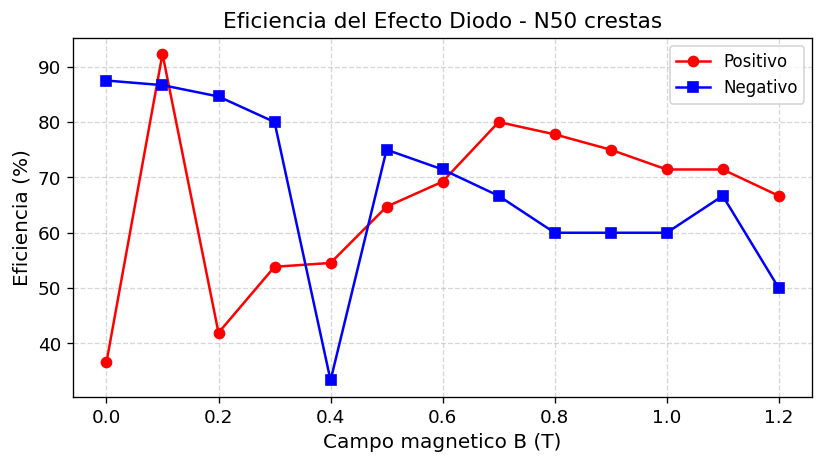

Grafica guardada: /home/camila/Documentos/Manizales/Resultados/Results/Eficiencias/eficiencia_N50_crestas.png


In [20]:
# ============================================================
# CELDA 2 - Salida N2_crestas: CSV y grafica
# ============================================================

_N = 50
save_csv(_N, global_results[_N]['pos'], global_results[_N]['neg'])
plot_cresta(_N, global_results[_N]['pos'], global_results[_N]['neg'])

In [21]:
# ============================================================
# CELDA 3 - N4_crestas: calculo de eficiencias
# ============================================================

_N = 4
_folder = next((f for f in cresta_folders if parse_N_value(f.name) == _N), None)

if _folder is not None:
    df_pos_4, df_neg_4 = process_cresta(_folder, _N)
    global_results[_N] = {'pos': df_pos_4, 'neg': df_neg_4}
    print_results(_N, df_pos_4, df_neg_4)
else:
    print(f"Carpeta N{_N}_crestas no encontrada - se omite.")
    df_pos_4, df_neg_4 = pd.DataFrame(), pd.DataFrame()
    global_results[_N] = {'pos': df_pos_4, 'neg': df_neg_4}

Carpeta N4_crestas no encontrada - se omite.


/tmp/ipykernel_37051/2779646457.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


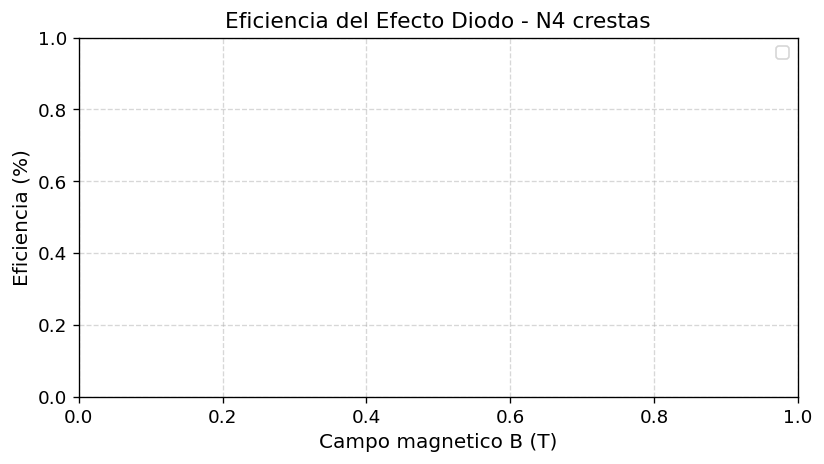

Grafica guardada: /home/camila/Documentos/Manizales/Resultados/Results/Eficiencias/eficiencia_N4_crestas.png


In [22]:
# ============================================================
# CELDA 4 - Salida N4_crestas: CSV y grafica
# ============================================================

_N = 4
save_csv(_N, global_results[_N]['pos'], global_results[_N]['neg'])
plot_cresta(_N, global_results[_N]['pos'], global_results[_N]['neg'])

In [23]:
# ============================================================
# CELDA 5 - N6_crestas: calculo de eficiencias
# ============================================================

_N = 6
_folder = next((f for f in cresta_folders if parse_N_value(f.name) == _N), None)

if _folder is not None:
    df_pos_6, df_neg_6 = process_cresta(_folder, _N)
    global_results[_N] = {'pos': df_pos_6, 'neg': df_neg_6}
    print_results(_N, df_pos_6, df_neg_6)
else:
    print(f"Carpeta N{_N}_crestas no encontrada - se omite.")
    df_pos_6, df_neg_6 = pd.DataFrame(), pd.DataFrame()
    global_results[_N] = {'pos': df_pos_6, 'neg': df_neg_6}

Carpeta N6_crestas no encontrada - se omite.


/tmp/ipykernel_37051/2779646457.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


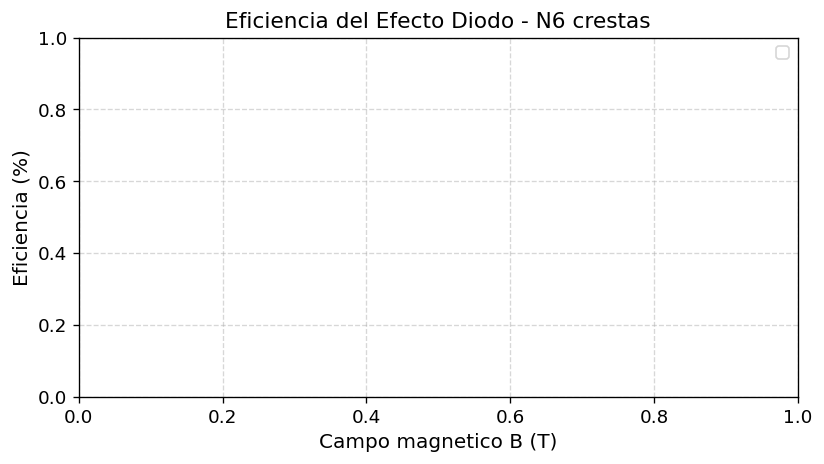

Grafica guardada: /home/camila/Documentos/Manizales/Resultados/Results/Eficiencias/eficiencia_N6_crestas.png


In [24]:
# ============================================================
# CELDA 6 - Salida N6_crestas: CSV y grafica
# ============================================================

_N = 6
save_csv(_N, global_results[_N]['pos'], global_results[_N]['neg'])
plot_cresta(_N, global_results[_N]['pos'], global_results[_N]['neg'])

In [25]:
# ============================================================
# CELDA 7 - N8_crestas: calculo de eficiencias
# ============================================================

_N = 8
_folder = next((f for f in cresta_folders if parse_N_value(f.name) == _N), None)

if _folder is not None:
    df_pos_8, df_neg_8 = process_cresta(_folder, _N)
    global_results[_N] = {'pos': df_pos_8, 'neg': df_neg_8}
    print_results(_N, df_pos_8, df_neg_8)
else:
    print(f"Carpeta N{_N}_crestas no encontrada - se omite.")
    df_pos_8, df_neg_8 = pd.DataFrame(), pd.DataFrame()
    global_results[_N] = {'pos': df_pos_8, 'neg': df_neg_8}

Carpeta N8_crestas no encontrada - se omite.


/tmp/ipykernel_37051/2779646457.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


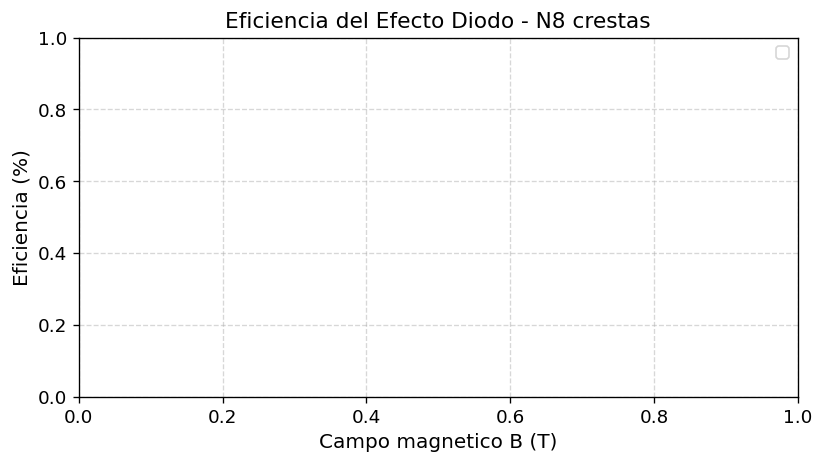

Grafica guardada: /home/camila/Documentos/Manizales/Resultados/Results/Eficiencias/eficiencia_N8_crestas.png


In [26]:
# ============================================================
# CELDA 8 - Salida N8_crestas: CSV y grafica
# ============================================================

_N = 8
save_csv(_N, global_results[_N]['pos'], global_results[_N]['neg'])
plot_cresta(_N, global_results[_N]['pos'], global_results[_N]['neg'])

In [27]:
# ============================================================
# CELDA 9 - N10_crestas: calculo de eficiencias
# ============================================================

_N = 10
_folder = next((f for f in cresta_folders if parse_N_value(f.name) == _N), None)

if _folder is not None:
    df_pos_10, df_neg_10 = process_cresta(_folder, _N)
    global_results[_N] = {'pos': df_pos_10, 'neg': df_neg_10}
    print_results(_N, df_pos_10, df_neg_10)
else:
    print(f"Carpeta N{_N}_crestas no encontrada - se omite.")
    df_pos_10, df_neg_10 = pd.DataFrame(), pd.DataFrame()
    global_results[_N] = {'pos': df_pos_10, 'neg': df_neg_10}

Carpeta N10_crestas no encontrada - se omite.


/tmp/ipykernel_37051/2779646457.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


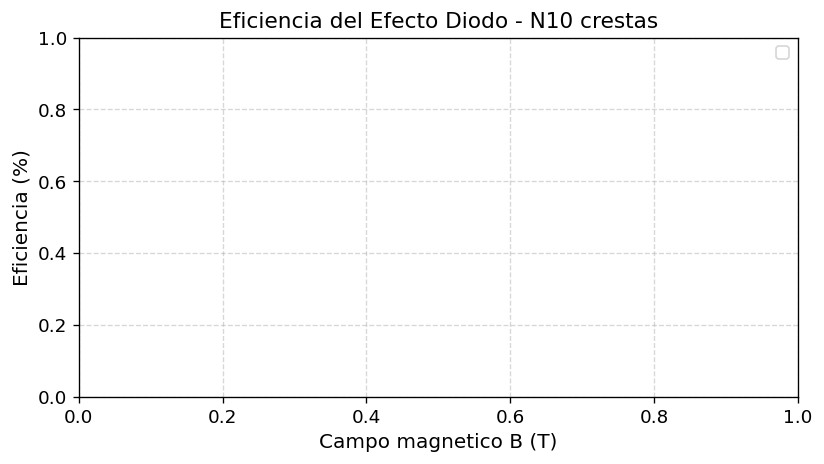

Grafica guardada: /home/camila/Documentos/Manizales/Resultados/Results/Eficiencias/eficiencia_N10_crestas.png


In [28]:
# ============================================================
# CELDA 10 - Salida N10_crestas: CSV y grafica
# ============================================================

_N = 10
save_csv(_N, global_results[_N]['pos'], global_results[_N]['neg'])
plot_cresta(_N, global_results[_N]['pos'], global_results[_N]['neg'])

In [29]:
# ============================================================
# CELDA AUTOMATICA - Procesamiento de cualquier N adicional
# detectado en la estructura de carpetas (extensible)
# ============================================================

# N fijos ya procesados arriba
N_procesados = {50, 4, 6, 8, 10}

for cresta_folder in cresta_folders:
    N = parse_N_value(cresta_folder.name)
    if N in N_procesados:
        continue
    print(f"--- Procesando N{N}_crestas (detectado automaticamente) ---")
    df_pos, df_neg = process_cresta(cresta_folder, N)
    global_results[N] = {'pos': df_pos, 'neg': df_neg}
    print_results(N, df_pos, df_neg)
    save_csv(N, df_pos, df_neg)
    plot_cresta(N, df_pos, df_neg)

CSV global guardado: /home/camila/Documentos/Manizales/Resultados/Results/Eficiencias/eficiencia_global.csv

 N_crestas  promedio_positivo  promedio_negativo  promedio_global
         4                NaN                NaN              NaN
         6                NaN                NaN              NaN
         8                NaN                NaN              NaN
        10                NaN                NaN              NaN
        50          65.804491          67.836715        66.820603



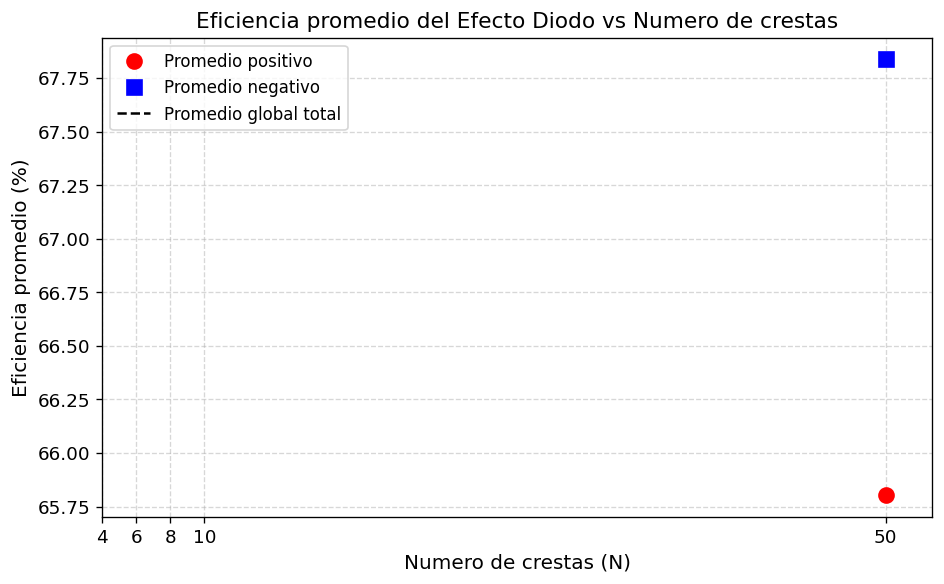

Grafica global guardada: /home/camila/Documentos/Manizales/Resultados/Results/Eficiencias/eficiencia_global.png


In [30]:
# ============================================================
# CELDA GLOBAL - Promedio de eficiencia por N*_crestas
# + CSV global + grafica global
# ============================================================

summary_rows = []

for N in sorted(global_results.keys()):
    df_pos = global_results[N]['pos']
    df_neg = global_results[N]['neg']

    avg_pos = df_pos['eficiencia'].mean() if not df_pos.empty else np.nan
    avg_neg = df_neg['eficiencia'].mean() if not df_neg.empty else np.nan

    vals = [v for v in [avg_pos, avg_neg] if not np.isnan(v)]
    avg_global = np.mean(vals) if vals else np.nan

    summary_rows.append({
        'N_crestas': N,
        'promedio_positivo': avg_pos,
        'promedio_negativo': avg_neg,
        'promedio_global': avg_global
    })

df_global = pd.DataFrame(summary_rows)

# Guardar CSV global
global_csv_path = OUTPUT_PATH / 'eficiencia_global.csv'
df_global.to_csv(global_csv_path, index=False)
print("CSV global guardado:", global_csv_path)
print()
print(df_global.to_string(index=False))
print()

# --- Grafica global ---
fig, ax = plt.subplots(figsize=(8, 5))

mask_pos = df_global['promedio_positivo'].notna()
mask_neg = df_global['promedio_negativo'].notna()
mask_glob = df_global['promedio_global'].notna()

ax.plot(
    df_global.loc[mask_pos, 'N_crestas'],
    df_global.loc[mask_pos, 'promedio_positivo'],
    'o', color='red', markersize=9, label='Promedio positivo', zorder=5
)
ax.plot(
    df_global.loc[mask_neg, 'N_crestas'],
    df_global.loc[mask_neg, 'promedio_negativo'],
    's', color='blue', markersize=9, label='Promedio negativo', zorder=5
)
ax.plot(
    df_global.loc[mask_glob, 'N_crestas'],
    df_global.loc[mask_glob, 'promedio_global'],
    'k--', linewidth=1.5, label='Promedio global total', zorder=4
)

ax.set_xlabel('Numero de crestas (N)')
ax.set_ylabel('Eficiencia promedio (%)')
ax.set_title('Eficiencia promedio del Efecto Diodo vs Numero de crestas')
ax.set_xticks(sorted(global_results.keys()))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

global_fig_path = OUTPUT_PATH / 'eficiencia_global.png'
fig.savefig(global_fig_path, dpi=150)
plt.show()
print(f"Grafica global guardada: {global_fig_path}")
plt.close(fig)